# Time-series example

This page is an end-to-end workflow for a **time-series** KPNN:
a named prior whose hidden nodes carry state across a sequence
`x_t`. You parse the graph, write the time loop, train a small
model, and interpret named nodes over time.

Read [Feedforward example](../feedforward-example/) first. That
tutorial is a feedforward `parse_layered()` network on a DAG.
[Cyclic graph example](../cyclic-graph-example/) is a feedback
prior on a **static** feature table. This page is what changes
when the data are a sequence.

What you get here:

- a tiny graph where a transcription factor has a self-loop, so
  its value at `t` can depend on `t-1`
- `parse_adjacency()`, which allows that self-loop
- why `parse_layered()` cannot parse this graph
- one shared `MaskedLinear` over all nodes, applied once per
  time with a **new** `x_t` written into the input nodes
- training on simulated sequences whose class is an **early**
  pulse (the last frame is not enough)
- Captum scores on named nodes with a `step` axis
- a control that drops the self-loop and cannot solve the task

The loop is ordinary PyTorch. Weights are shared across time.
`kpnn2` does not unroll time, pick the sequence length, or ship
`MaskedRNN`. `nn.RNN` / `nn.GRU` / `nn.LSTM` cannot take an
edgelist; they own dense `W_ih` / `W_hh`. A GRU or LSTM is the
usual gate equations with one `MaskedLinear` per map in your
`forward()`.


In [1]:
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2

In [2]:
from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 14
_FIG_W = 7.0
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)
sns.set_theme(
    style="ticks",
    rc=_plot_rc,
)


def _new_fig(height):
    return plt.figure(figsize=(_FIG_W, height))


def _style_ax(ax):
    ax.tick_params(labelsize=_FONT_SIZE)
    ax.title.set_fontsize(_FONT_SIZE)
    ax.xaxis.label.set_size(_FONT_SIZE)
    ax.yaxis.label.set_size(_FONT_SIZE)
    ax.set_facecolor("none")
    ax.grid(False)

## Define the graph

Two genes feed two transcription factors. `tf_signal` has a
self-loop, so it can integrate `gene_signal` across time.
`tf_noise` is a distractor with no memory. Both TFs feed
`output_1`.

- `gene_signal` → `tf_signal` (and `tf_signal` → `tf_signal`)
- `gene_noise` → `tf_noise`
- both TFs → `output_1`

The edgelist format is the same two columns as
[Feedforward example](../feedforward-example/): `source` and
`target`. `parse_layered()` rejects a self-loop. That is why
this layout uses `parse_adjacency()`.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_signal",
            "gene_noise",
            "tf_signal",
            "tf_signal",
            "tf_noise",
        ],
        "target": [
            "tf_signal",
            "tf_noise",
            "tf_signal",
            "output_1",
            "output_1",
        ],
    }
)

edgelist

,source,target
0,gene_signal,tf_signal
1,gene_noise,tf_noise
2,tf_signal,tf_signal
3,tf_signal,output_1
4,tf_noise,output_1


In [4]:
try:
    kpnn2.parse_layered(edgelist)
except kpnn2.Kpnn2Error as error:
    print(error)

Edgelist contains 1 self-loop(s): tf_signal. Self-loops are not allowed.


In [5]:
spec = kpnn2.parse_adjacency(edgelist)

(
    spec.nodes,
    spec.input_nodes,
    spec.hidden_nodes,
    spec.output_nodes,
)

(('gene_noise', 'gene_signal', 'output_1', 'tf_noise', 'tf_signal'),
 ('gene_noise', 'gene_signal'),
 ('tf_noise', 'tf_signal'),
 ('output_1',))

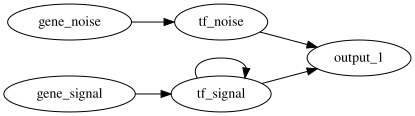

In [6]:
dot = Digraph()
dot.attr(rankdir="LR")

for node_name in spec.nodes:
    dot.node(
        node_name,
        node_name,
    )

for row in edgelist.itertuples(index=False):
    dot.edge(
        str(row.source),
        str(row.target),
    )

dot

## Shared masked update over time

This is the same structural work as
[Cyclic graph example](../cyclic-graph-example/). The difference
is the data: cyclic re-injects the **same** `x` so a signal can
travel around a feedback edge. Here each step gets a new `x_t`.

`parse_adjacency()` already did:

1. named node sets: `spec.input_nodes`, `spec.hidden_nodes`,
   `spec.output_nodes`
2. packed edges; `spec.to_mask()` is the dense square for this
   small graph
3. where inputs and outputs sit in the state vector:
   `spec.input_index`, `spec.output_index`

The rest is ordinary PyTorch:

4. wrap `spec.to_mask()` in `MaskedLinear`
5. for each time `t`, write `x_t` into the input slots, apply
   that shared layer, keep the state
6. read the output nodes after the last step and apply a linear
   head

`n_steps` is the sequence length you chose. `kpnn2` does not
unroll time.

Writing the inputs each step is required, not cosmetic. Input
nodes have in-degree 0, so their rows of `to_mask()` are zeros
and `fan_in` is 0. Under the degree-aware init those rows stay
at zero, so nothing would ever copy `x_t` into the state unless
we do it.

This graph is small, so `MaskedLinear` is appropriate. See
[PackedLinear](../packed_linear/) when `n_nodes` is large.

Each unrolled time is its own `nn.Module` so Captum can hook it.
They all share the same `MaskedLinear` weights.


In [7]:
class TimeStep(nn.Module):
    def __init__(self, linear, input_index):
        super().__init__()
        # Shared MaskedLinear: do not register it as a child.
        object.__setattr__(self, "_linear", linear)
        self.input_index = input_index

    def forward(self, state, x_t):
        state = state.clone()
        state[:, self.input_index] = x_t
        return torch.relu(self._linear(state))


class TimeSeriesNet(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        n_steps: int,
    ):
        super().__init__()
        self.spec = spec
        self.core = kpnn2.MaskedLinear(spec.to_mask())
        self.steps = nn.ModuleList(
            [
                TimeStep(
                    self.core,
                    spec.input_index,
                )
                for _ in range(n_steps)
            ]
        )
        self.head = nn.Linear(
            len(spec.output_nodes),
            1,
        )

    def forward(self, x):
        n_nodes = self.core.in_features
        state = x.new_zeros(x.shape[0], n_nodes)
        for t, step in enumerate(self.steps):
            state = step(state, x[:, t, :])
        output = state[:, self.spec.output_index]
        return self.head(output)

In [8]:
n_steps = 6
model = TimeSeriesNet(
    spec,
    n_steps,
)
spec.nodes, spec.input_index, len(model.steps)

(('gene_noise', 'gene_signal', 'output_1', 'tf_noise', 'tf_signal'), (0, 1), 6)

## Simulate sequences, align, and train

Each sample is `n_steps` frames of the two genes. Class 1 has a
positive pulse on `gene_signal` at times 0 and 1. Class 0 does
not. `gene_noise` is uninformative at every time. The last frame
looks similar in both classes, so a model without memory cannot
separate them.

`align_inputs()` still wants a table of named columns, one row
per aligned vector. Flatten `(sample, time)` into rows, align,
then reshape to `(n_samples, n_steps, n_inputs)`. Pre-ordered
dense tensors can skip that and go straight to the model.


In [9]:
def simulate_sequences(
    n_per_class,
    n_steps,
    feature_names,
    pulse_times,
    rng,
):
    n_features = len(feature_names)
    n_samples = 2 * n_per_class
    x = rng.normal(
        0.0,
        1.0,
        size=(n_samples, n_steps, n_features),
    )
    y = np.array([0] * n_per_class + [1] * n_per_class)
    signal_idx = feature_names.index("gene_signal")
    class_1 = y == 1
    for time in pulse_times:
        x[class_1, time, signal_idx] += 1.8
    return x, y


def series_to_frame(x, feature_names):
    n_samples, n_times, _ = x.shape
    rows = []
    for i in range(n_samples):
        for time in range(n_times):
            row = {
                name: float(x[i, time, j])
                for j, name in enumerate(feature_names)
            }
            rows.append(row)
    return pd.DataFrame(rows)


feature_names = list(spec.input_nodes)
rng = np.random.default_rng(42)
pulse_times = (0, 1)

x_train_np, y_train = simulate_sequences(
    n_per_class=80,
    n_steps=n_steps,
    feature_names=feature_names,
    pulse_times=pulse_times,
    rng=rng,
)
x_test_np, y_test = simulate_sequences(
    n_per_class=40,
    n_steps=n_steps,
    feature_names=feature_names,
    pulse_times=pulse_times,
    rng=rng,
)

x_train_np.shape, feature_names

((160, 6, 2), ['gene_noise', 'gene_signal'])

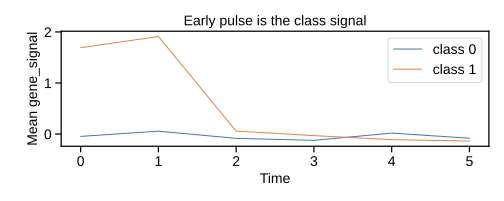

In [10]:
signal_idx = feature_names.index("gene_signal")
fig = _new_fig(2.8)
ax = fig.add_subplot(1, 1, 1)
for label, name in ((0, "class 0"), (1, "class 1")):
    series = x_train_np[y_train == label, :, signal_idx]
    ax.plot(
        range(n_steps),
        series.mean(axis=0),
        label=name,
    )
ax.set_xlabel("Time")
ax.set_ylabel("Mean gene_signal")
ax.set_title("Early pulse is the class signal")
ax.legend()
_style_ax(ax)
plt.tight_layout()
plt.show()

Loss before first update: 0.6929
Loss after final update:  0.2392
Test accuracy: 0.887


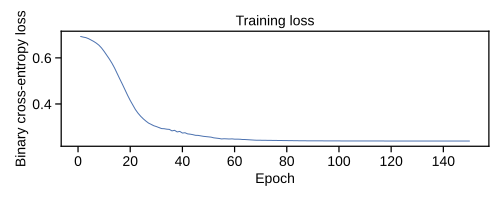

In [11]:
x_train_flat = kpnn2.align_inputs(
    series_to_frame(x_train_np, feature_names),
    spec,
)
x_test_flat = kpnn2.align_inputs(
    series_to_frame(x_test_np, feature_names),
    spec,
)
n_inputs = len(spec.input_nodes)
x_train = x_train_flat.reshape(
    x_train_np.shape[0],
    n_steps,
    n_inputs,
)
x_test = x_test_flat.reshape(
    x_test_np.shape[0],
    n_steps,
    n_inputs,
)

y_train_tensor = torch.tensor(
    y_train.reshape(-1, 1),
    dtype=torch.float32,
)
y_test_tensor = torch.tensor(
    y_test.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.05,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []
model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

model.eval()
with torch.no_grad():
    pred = (model(x_test) > 0).float()
    test_acc = (pred == y_test_tensor).float().mean().item()

print(
    "Loss before first update:",
    round(loss_history[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history[-1], 4),
)
print("Test accuracy:", round(test_acc, 3))

fig = _new_fig(2.8)
ax = fig.add_subplot(1, 1, 1)
ax.plot(
    range(1, n_epochs + 1),
    loss_history,
    linewidth=1,
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy loss")
ax.set_title("Training loss")
_style_ax(ax)
plt.tight_layout()
plt.show()

## Interpret nodes over time

Captum `LayerConductance` is run on each unrolled step. Then
`map_node_attributions()` labels the sequence of
`(batch, n_nodes)` tensors. Passing several tensors stacks them
on a `step` axis. `kpnn2` does not import Captum. For the mapper
itself, see
[Mapping attributions](../map-node-attributions/).

There is no `layer=` argument. An `AdjacencySpec` has no depths,
so the node axis is the whole state vector (`spec.nodes`).

Scores are on each step's **output** state. Input rows of
`to_mask()` are structurally zero, so `gene_signal` does not
appear there. The pulse shows up on `tf_signal` while that
memory still reaches the head, and on `output_1` at the last
step, which is the only unit the head reads. `gene_noise`
stays near zero.


In [12]:
from captum.attr import LayerConductance

model.eval()
per_step = []
for step in model.steps:
    conductor = LayerConductance(
        model,
        step,
    )
    attributions = conductor.attribute(
        x_test,
        target=0,
    )
    per_step.append(attributions)

da = kpnn2.map_node_attributions(
    attributions=tuple(per_step),
    spec=spec,
)
da.dims, tuple(da["node"].values)

(('step', 'observation', 'node'),
 (np.str_('gene_noise'),
  np.str_('gene_signal'),
  np.str_('output_1'),
  np.str_('tf_noise'),
  np.str_('tf_signal')))

node,gene_noise,gene_signal,output_1,tf_noise,tf_signal
step,,,,,
0,0.0,0.0,0.000,0.000,2.387
1,0.0,0.0,0.000,0.000,3.680
2,0.0,0.0,0.000,0.000,3.705
3,0.0,0.0,0.000,0.000,3.768
4,0.0,0.0,0.000,0.677,3.860
5,0.0,0.0,3.959,0.000,0.000


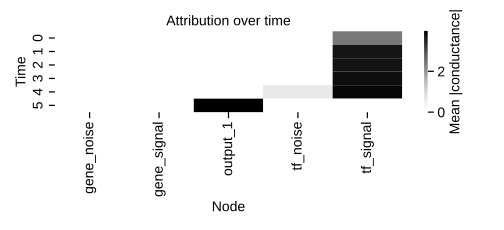

In [13]:
mean_abs = np.abs(da).mean("observation").to_pandas()
mean_abs.index = mean_abs.index.map(str)
display(mean_abs.round(3))

fig = _new_fig(3.2)
ax = fig.add_subplot(1, 1, 1)
sns.heatmap(
    mean_abs,
    ax=ax,
    cmap="Greys",
    cbar_kws={"label": "Mean |conductance|"},
)
ax.set_xlabel("Node")
ax.set_ylabel("Time")
ax.set_title("Attribution over time")
_style_ax(ax)
plt.tight_layout()
plt.show()

## Why not `nn.RNN`?

`nn.RNN`, `nn.GRU`, and `nn.LSTM` are fused convenience modules.
An Elman step is a linear map plus a nonlinearity; GRU and LSTM
add more linear maps and the gate mix. PyTorch bundles the maps,
the time loop, packing, and (on GPU) fused kernels.

Those maps are dense packed parameters, not `nn.Linear` children
you can swap. There is no edgelist slot, so they cannot be the
recurrent map of a KPNN. Zeroing their weights after the fact is
not equivalent to `MaskedLinear`: the optimizer can fill the
zeros, init is not degree-aware, and names do not follow
`spec.nodes`.

There is no `MaskedRNN` in `kpnn2`. The module above is the
assembly: `MaskedLinear` as the map, `for t` in your
`forward()`. That is short because a knowledge-primed Elman net
does not need packed sequences, cuDNN fusion, or bidirectional
stacks. Those are why PyTorch ships `nn.RNN`; a masked square
would not get them anyway.

A GRU or LSTM is the same idea with more maps. Each gate is a
`MaskedLinear` (the same `spec.to_mask()`, or a different
edgelist if you want a different prior per gate). The gate
equations stay ordinary PyTorch in your `nn.Module`. Whether
every gate shares one prior is a modeling choice, not something
`parse_adjacency()` decides.


## Control: no self-loop, no memory

Drop `tf_signal → tf_signal`. The genes, TFs, and output are
unchanged, and the data are the same early pulse. Each step then
reads only the current `x_t`, so the class signal is gone by the
last frame.


In [14]:
edgelist_no_memory = pd.DataFrame(
    {
        "source": [
            "gene_signal",
            "gene_noise",
            "tf_signal",
            "tf_noise",
        ],
        "target": [
            "tf_signal",
            "tf_noise",
            "output_1",
            "output_1",
        ],
    }
)
spec_no_memory = kpnn2.parse_adjacency(edgelist_no_memory)
torch.manual_seed(42)
model_no_memory = TimeSeriesNet(
    spec_no_memory,
    n_steps,
)

optimizer = torch.optim.Adam(
    model_no_memory.parameters(),
    lr=0.05,
)
loss_history_no_memory = []
model_no_memory.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model_no_memory(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history_no_memory.append(loss.item())

model_no_memory.eval()
with torch.no_grad():
    pred = (model_no_memory(x_test) > 0).float()
    acc_no_memory = (pred == y_test_tensor).float().mean().item()

print(
    "Loss before first update:",
    round(loss_history_no_memory[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history_no_memory[-1], 4),
)
print("Test accuracy:", round(acc_no_memory, 3))

Loss before first update: 0.6936
Loss after final update:  0.6868
Test accuracy: 0.463


Without the self-loop the loss stays near chance and test
accuracy does not separate the classes. The time loop was the
same; only the prior lost the edge that carries state. That is
the time-series analogue of a missing path in a static KPNN.
